11:41:15 - cmdstanpy - INFO - Chain [1] start processing



= Prophet Modeling for BETH-USD =


11:41:15 - cmdstanpy - INFO - Chain [1] done processing
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Metrics for BETH-USD: RMSE=1146.6083, MAE=997.8032, MAPE=41.84%, R2=-9.9227
Saved historical forecast CSV: ../../results/Prophet_csv/separate_coins/BETH-USD_historical_forecast.csv
Saved test forecast CSV: ../../results/Prophet_csv/separate_coins/BETH-USD_test_forecast.csv
Saved future forecast CSV: ../../results/Prophet_csv/separate_coins/BETH-USD_future_forecast.csv
Saved model pickle: ../../saved_models/prophet_model_BETH-USD.pkl


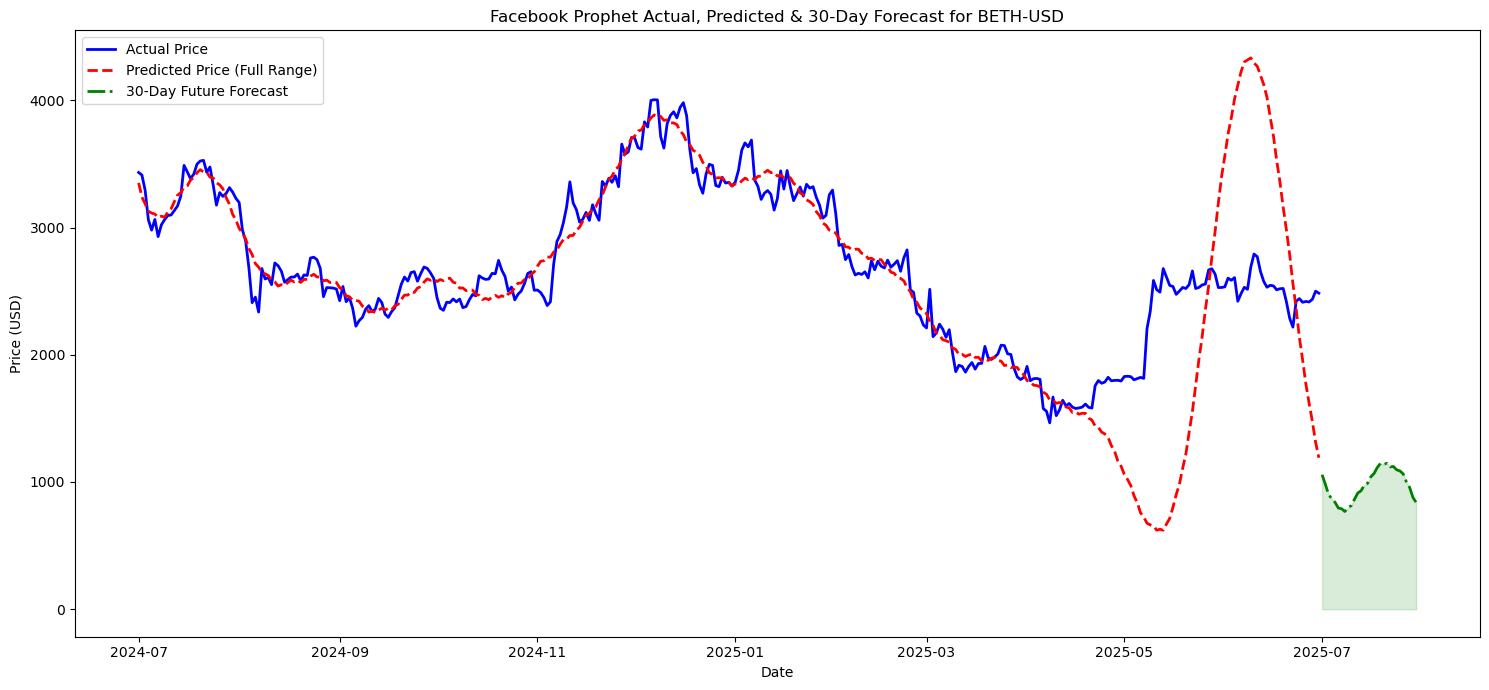


= Prophet Modeling for BTC-USD =


11:41:15 - cmdstanpy - INFO - Chain [1] start processing
11:41:15 - cmdstanpy - INFO - Chain [1] done processing


Metrics for BTC-USD: RMSE=7656.0072, MAE=5849.3041, MAPE=5.55%, R2=-0.6212
Saved historical forecast CSV: ../../results/Prophet_csv/separate_coins/BTC-USD_historical_forecast.csv
Saved test forecast CSV: ../../results/Prophet_csv/separate_coins/BTC-USD_test_forecast.csv
Saved future forecast CSV: ../../results/Prophet_csv/separate_coins/BTC-USD_future_forecast.csv
Saved model pickle: ../../saved_models/prophet_model_BTC-USD.pkl


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


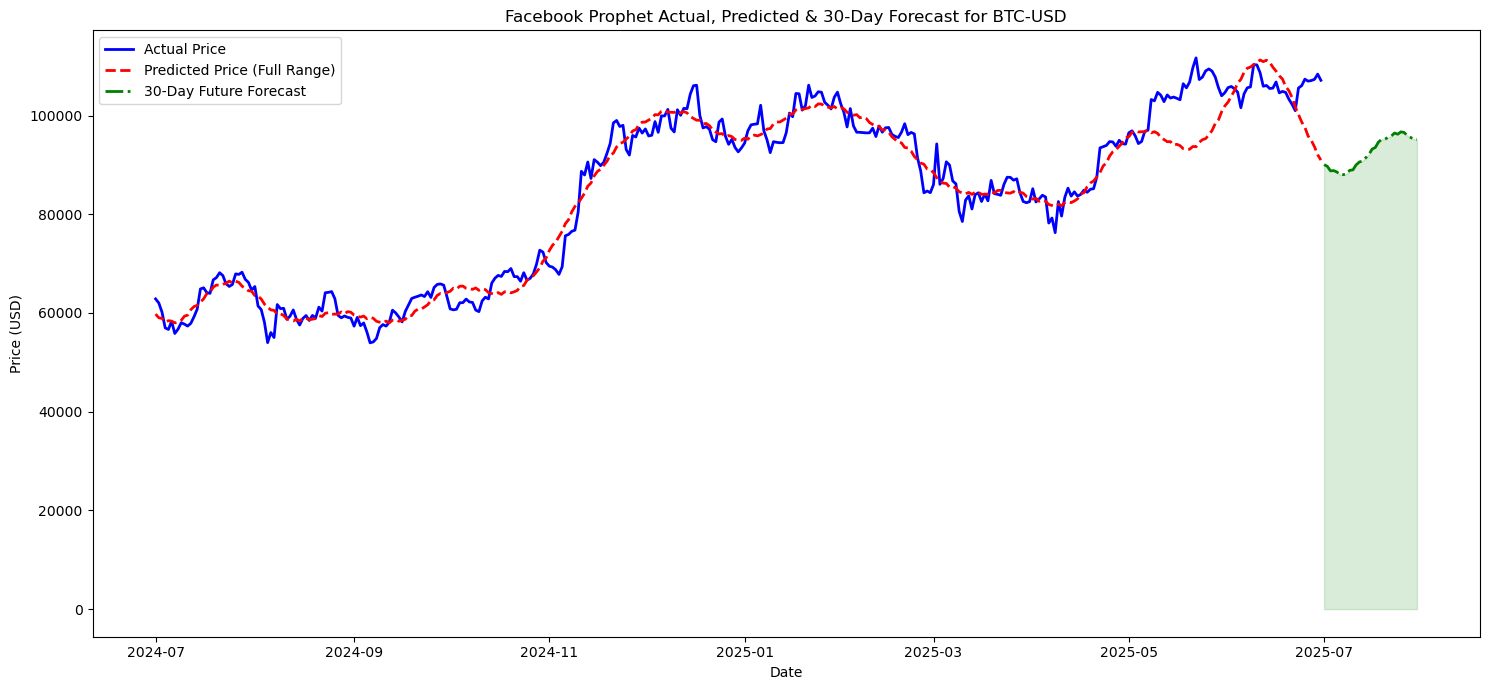

11:41:15 - cmdstanpy - INFO - Chain [1] start processing
11:41:15 - cmdstanpy - INFO - Chain [1] done processing



= Prophet Modeling for ADA-USD =
Metrics for ADA-USD: RMSE=0.1424, MAE=0.1143, MAPE=17.58%, R2=-2.7539
Saved historical forecast CSV: ../../results/Prophet_csv/separate_coins/ADA-USD_historical_forecast.csv
Saved test forecast CSV: ../../results/Prophet_csv/separate_coins/ADA-USD_test_forecast.csv
Saved future forecast CSV: ../../results/Prophet_csv/separate_coins/ADA-USD_future_forecast.csv
Saved model pickle: ../../saved_models/prophet_model_ADA-USD.pkl


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


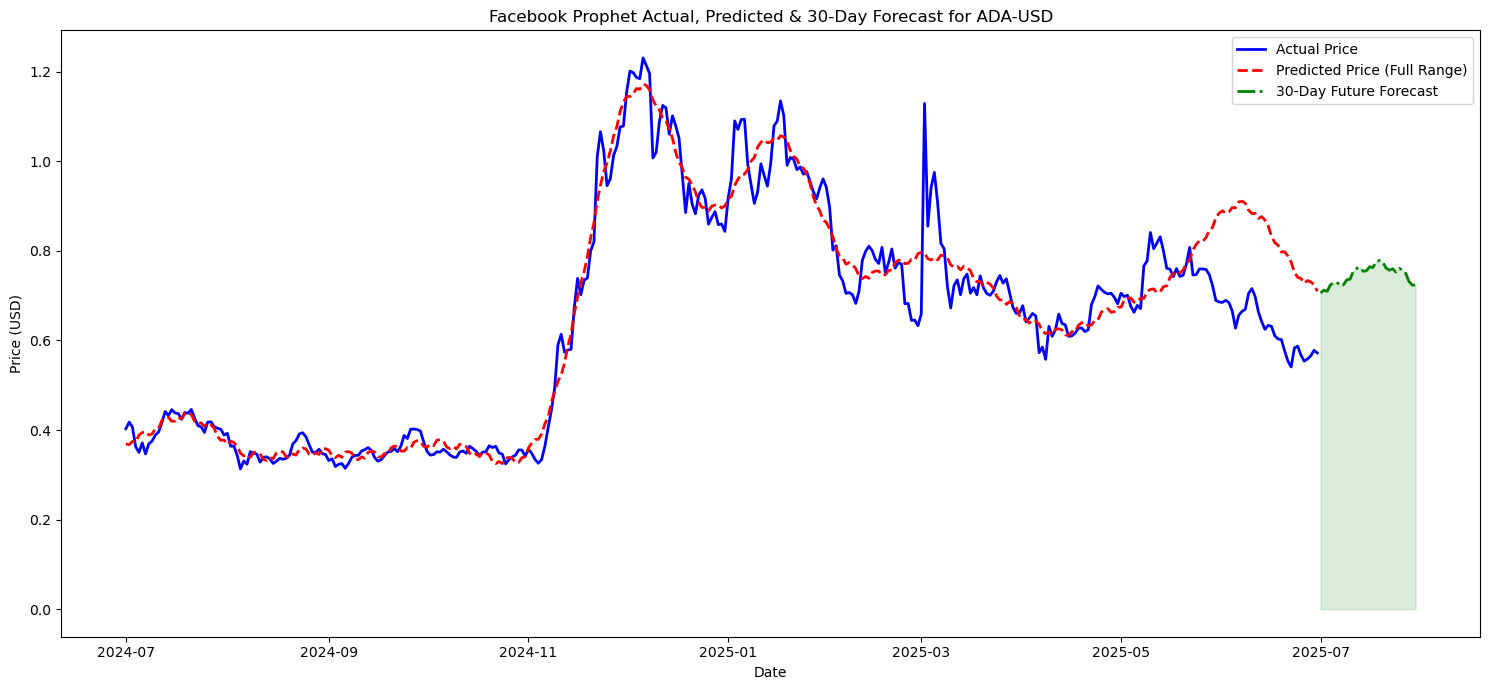

11:41:16 - cmdstanpy - INFO - Chain [1] start processing
11:41:16 - cmdstanpy - INFO - Chain [1] done processing



= Prophet Modeling for BCH-USD =
Metrics for BCH-USD: RMSE=177.0924, MAE=152.8287, MAPE=37.18%, R2=-15.6787
Saved historical forecast CSV: ../../results/Prophet_csv/separate_coins/BCH-USD_historical_forecast.csv
Saved test forecast CSV: ../../results/Prophet_csv/separate_coins/BCH-USD_test_forecast.csv
Saved future forecast CSV: ../../results/Prophet_csv/separate_coins/BCH-USD_future_forecast.csv
Saved model pickle: ../../saved_models/prophet_model_BCH-USD.pkl


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


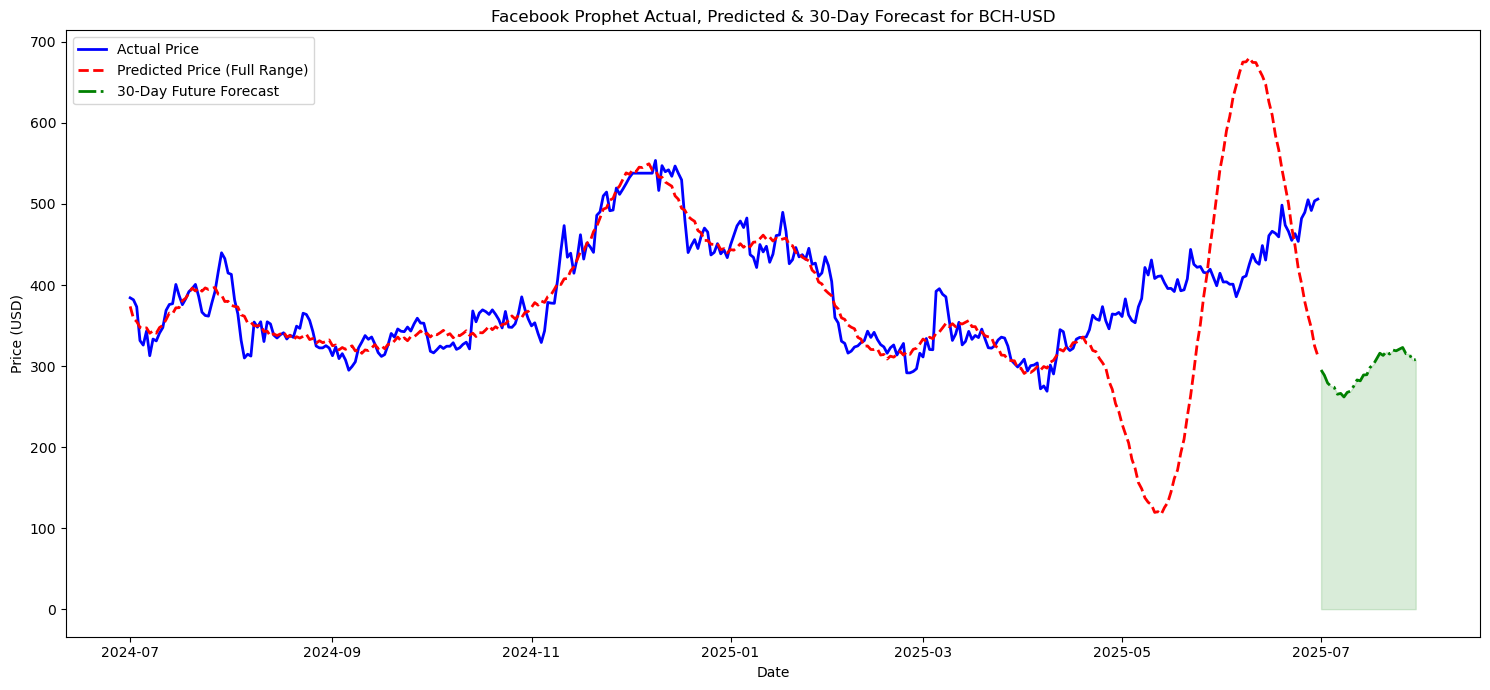

Saved combined metrics CSV: ../../results/Prophet_csv/separate_coins/prophet_metrics_summary.csv


In [2]:
import os
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from prophet import Prophet
import matplotlib.pyplot as plt
import pickle

def generate_signals(prices):
    signals = ['Hold']
    for i in range(1, len(prices)):
        if prices[i] > prices[i-1]:
            signals.append('Buy')
        elif prices[i] < prices[i-1]:
            signals.append('Sell')
        else:
            signals.append('Hold')
    return signals

# Load cleaned dataset and representative coins
df = pd.read_csv('../../data/cleaned/crypto_dataset_cleaned.csv', parse_dates=['Date'], index_col='Date')
rep_df = pd.read_csv('../../data/processed/representative_coins.csv')
rep_coins = rep_df['Representative_Coin'].tolist()

output_dir = '../../results/Prophet_csv/separate_coins'
os.makedirs(output_dir, exist_ok=True)
models_dir = '../../saved_models'
os.makedirs(models_dir, exist_ok=True)

metrics_list = []

for coin in rep_coins:
    print(f"\n= Prophet Modeling for {coin} =")

    # Prepare continuous data starting from 2024-07-01 with forward fill
    coin_df = df[[coin]].copy().ffill()
    coin_df = coin_df.reset_index()
    coin_df.rename(columns={'Date': 'ds', coin: 'y'}, inplace=True)
    coin_df['ds'] = pd.to_datetime(coin_df['ds'])

    desired_start = pd.Timestamp('2024-07-01')
    if coin_df['ds'].min() > desired_start:
        all_dates = pd.date_range(start=desired_start, end=coin_df['ds'].max())
        coin_df = coin_df.set_index('ds').reindex(all_dates).rename_axis('ds').reset_index()
        coin_df['y'] = coin_df['y'].ffill()
    coin_df = coin_df.dropna(subset=['y'])

    # Train-test split
    train_size = int(len(coin_df) * 0.8)
    train_df = coin_df.iloc[:train_size].copy()
    test_df = coin_df.iloc[train_size:].copy()

    # Train Prophet model
    model = Prophet(daily_seasonality=True, yearly_seasonality=True)
    model.fit(train_df)

    # Predict full historical range (train+test)
    full_forecast = model.predict(coin_df[['ds']])
    y_pred_full = full_forecast['yhat'].values

    # Predicted on test only for metrics and plotting
    y_pred_test = y_pred_full[train_size:]
    y_actual_test = test_df['y'].values

    # Calculate metrics (test period)
    rmse = mean_squared_error(y_actual_test, y_pred_test, squared=False)
    mae = mean_absolute_error(y_actual_test, y_pred_test)
    mape = np.mean(np.abs((y_actual_test - y_pred_test) / (y_actual_test + 1e-10))) * 100
    r2 = r2_score(y_actual_test, y_pred_test)
    metrics_list.append({'Coin': coin, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2})
    print(f"Metrics for {coin}: RMSE={rmse:.4f}, MAE={mae:.4f}, MAPE={mape:.2f}%, R2={r2:.4f}")

    # Historical forecast CSV (full range) with signals
    hist_forecast_df = coin_df.copy()
    hist_forecast_df['Actual'] = coin_df['y']
    hist_forecast_df['Predicted'] = y_pred_full
    hist_forecast_df['Signal'] = generate_signals(y_pred_full)
    hist_forecast_df.rename(columns={'ds': 'Date'}, inplace=True)

    hist_csv_path = os.path.join(output_dir, f"{coin}_historical_forecast.csv")
    hist_forecast_df.to_csv(hist_csv_path, index=False)
    print(f"Saved historical forecast CSV: {hist_csv_path}")

    # Test forecast CSV with signals
    test_forecast_df = test_df.copy()
    test_forecast_df['Predicted'] = y_pred_test
    test_forecast_df['Signal'] = generate_signals(y_pred_test)
    test_forecast_df.rename(columns={'ds': 'Date', coin:'Actual'}, inplace=True)

    test_csv_path = os.path.join(output_dir, f"{coin}_test_forecast.csv")
    test_forecast_df.to_csv(test_csv_path, index=False)
    print(f"Saved test forecast CSV: {test_csv_path}")

    # Future 30-day forecast with signals
    last_date = coin_df['ds'].max()
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30, freq='D')
    future_df = pd.DataFrame({'ds': future_dates})

    future_forecast = model.predict(future_df)
    future_predicted = future_forecast['yhat'].values
    future_forecast_df = pd.DataFrame({
        'Date': future_dates,
        'Predicted': future_predicted,
        'Signal': generate_signals(future_predicted)
    })

    future_csv_path = os.path.join(output_dir, f"{coin}_future_forecast.csv")
    future_forecast_df.to_csv(future_csv_path, index=False)
    print(f"Saved future forecast CSV: {future_csv_path}")

    # Save the model pickle
    model_path = os.path.join(models_dir, f'prophet_model_{coin}.pkl')
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)
    print(f"Saved model pickle: {model_path}")

    # Plot full actual, predicted, and future 30-day forecast
    plt.figure(figsize=(15, 7))
    plt.plot(coin_df['ds'], coin_df['y'], label='Actual Price', color='blue', linewidth=2)
    plt.plot(coin_df['ds'], y_pred_full, label='Predicted Price (Full Range)', color='red', linestyle='--', linewidth=2)
    plt.plot(future_dates, future_predicted, label='30-Day Future Forecast', color='green', linestyle='dashdot', linewidth=2)
    plt.fill_between(future_dates, future_predicted, alpha=0.15, color='green')
    plt.title(f"Facebook Prophet Actual, Predicted & 30-Day Forecast for {coin}")
    plt.xlabel("Date")
    plt.ylabel("Price (USD)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Save combined metrics CSV for all coins
metrics_df = pd.DataFrame(metrics_list)
summary_metrics_path = os.path.join(output_dir, 'prophet_metrics_summary.csv')
metrics_df.to_csv(summary_metrics_path, index=False)
print(f"Saved combined metrics CSV: {summary_metrics_path}")
